In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv


In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
import keras
from keras import Sequential
from keras.layers import Dense,SimpleRNN,Embedding,Flatten
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.utils import pad_sequences
from keras.callbacks import EarlyStopping

In [3]:
df = pd.read_csv('/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [5]:
df.describe(include='all')

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [6]:
df.isna().sum().sum()

np.int64(0)

In [7]:
le = LabelEncoder()
# encoding sentements
df['sentiment'] = le.fit_transform(df['sentiment'])

In [8]:
# integer tokenize the reviews
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['review'])

sequences = tokenizer.texts_to_sequences(df['review'])
sequences = pad_sequences(sequences,padding='post',maxlen=50)
print(sequences[0])

[  504    20   642     2    76   243    16     9    69  7598   651   710
  6904   109   662    82  1208 19395   693     5    65   574     4   920
  2021    38  1208   559   147  3184    22   200   426  3819    16    48
     6  3314   805  1603    43    22    67    76     8  1228    16   125
  4103   486]


In [9]:
# spliting data into feature and labels
X = sequences
y = df['sentiment']

# spliting in train and test set
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
print("Shapes: ")
print("X_train: ",X_train.shape)
print("y_train: ",y_train.shape)
print("X_test : ",X_test.shape)
print("y_test : ",y_test.shape)

Shapes: 
X_train:  (40000, 50)
y_train:  (40000,)
X_test :  (10000, 50)
y_test :  (10000,)


In [11]:
X_train[:5]

array([[    3,   111,    12,  1569,   472,    75,   221,     5,   327,
            2,  3498,    35,    23,    51,    71,  1890,  4808,    14,
            9,  1388,    11,    19,     6,     3,  3574,  2064,    16,
           61,     1,  2414,   469,   533,     2,     3,   171,  2643,
        19293,  2811,  1776,     5,   586,     9,    36,     1,  3933,
          454,   156,   206,   352,  3944],
       [  110,    62, 11137,    16,     1,    79,   102,     8,     1,
           17,     2,   645,  4770,     6,  1099,  6494,   556,    15,
          264,     5,  2479,   925,     2,     1,   202,   134,  1190,
           34,   718,     2,  7542,    29,     1,   616,   463,   225,
           96,  1077,    11,    17,    98,    25,    75,  1712,    18,
            9,   213,    89,   103,     9],
       [ 2199,  1666,    14,    69,    14,     3,    49,   658,     2,
          361,     3,  6388,  1426,     6,    52,  3482,     5,    87,
           14,     1,    64,  4162,    73,    63,     1,  13

In [12]:
y[:5]

0    1
1    1
2    1
3    0
4    1
Name: sentiment, dtype: int64

In [13]:
print("total Vocabulary: ",len(tokenizer.word_index))

total Vocabulary:  124252


In [19]:
# model building
# input_shape = (input-shape,timestamp)

model = Sequential()

model.add(Embedding(124253,output_dim=2,input_length=50))
model.add(SimpleRNN(32,return_sequences=True))
model.add(SimpleRNN(32))
model.add(Dense(1,activation='sigmoid'))

# we dont need all outputs we need only final output 
# hence we used this: return_sequences=False

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
callback = EarlyStopping(
    monitor='val_loss', # watches validation loss each epoch
    verbose=1,
    patience=3,             
    restore_best_weights=True  # rolls back to the best epoch's weights when it stops
)

In [26]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

history = model.fit(X_train,y_train,epochs=10,validation_split=0.2,callbacks=callback)

Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 22s 20ms/step - accuracy: 0.9843 - loss: 0.0468 - val_accuracy: 0.7680 - val_loss: 0.8851
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.9863 - loss: 0.0419 - val_accuracy: 0.7750 - val_loss: 0.9573
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.9906 - loss: 0.0309 - val_accuracy: 0.7765 - val_loss: 1.0305
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.9916 - loss: 0.0269 - val_accuracy: 0.7750 - val_loss: 0.9854
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


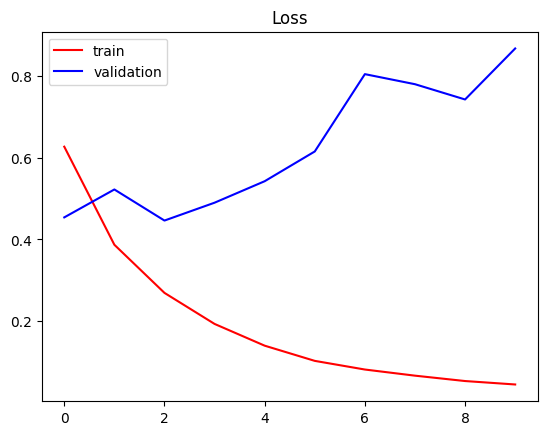

In [22]:
plt.title('Loss')
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

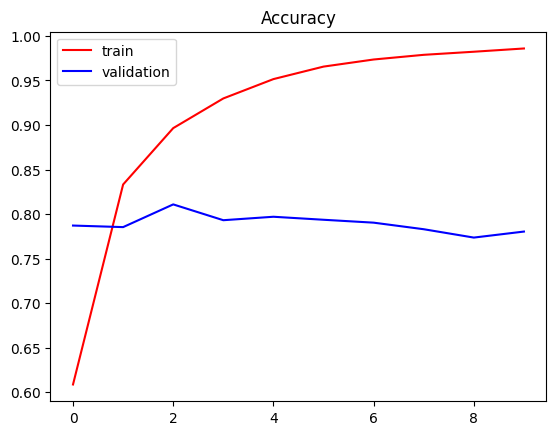

In [23]:
plt.title('Accuracy')
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

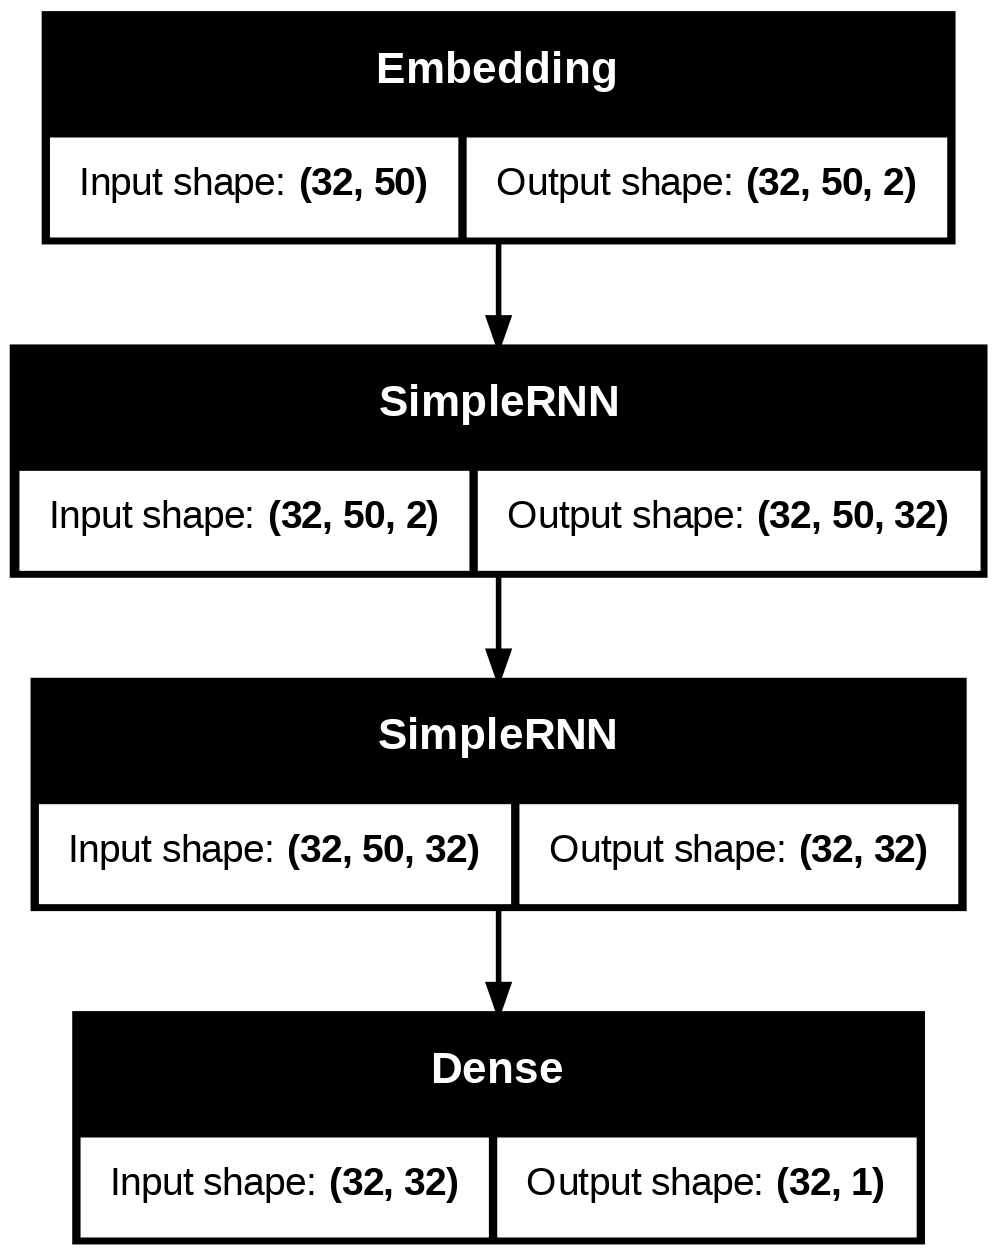

In [24]:
from keras.utils import plot_model

plot_model(model,show_shapes=True)